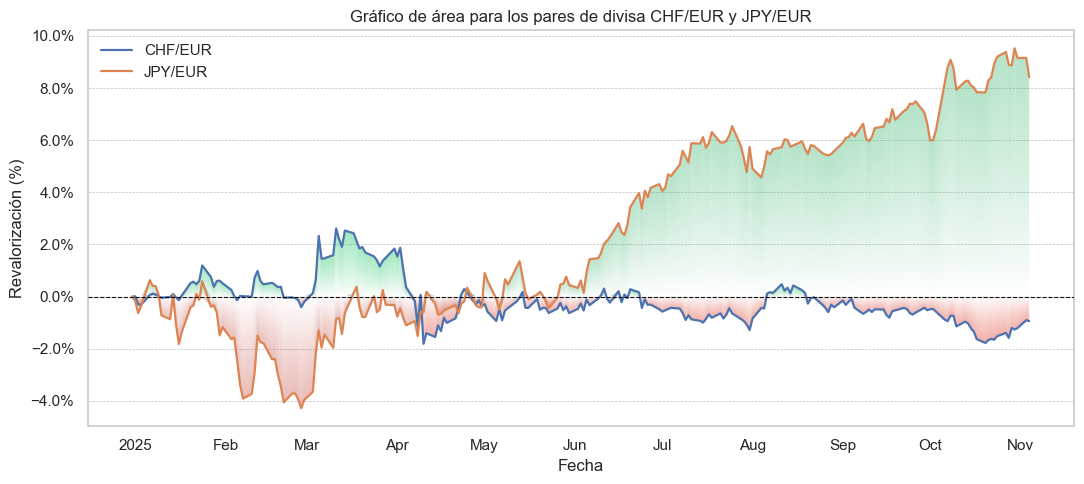

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

df = pd.read_csv('datos_area_chart.csv')

def area_gradiente_signed(ax, x, y,
                          color_pos="#2ecc71", color_neg="#e74c3c",
                          n_bandas=80, alpha_max=0.6):
    y = np.asarray(y, dtype=float)
    y_pos = np.clip(y, 0, np.inf)
    y_neg = np.clip(y, -np.inf, 0)

    for i in range(1, n_bandas + 1):
        t0 = (i - 1) / n_bandas
        t1 = i / n_bandas
        alpha = alpha_max * t1

        y0p, y1p = t0 * y_pos, t1 * y_pos
        ax.fill_between(x, y0p, y1p, where=(y_pos > 0), interpolate=True,
                        facecolor=color_pos, alpha=alpha, linewidth=0)

        y0n, y1n = t0 * y_neg, t1 * y_neg
        ax.fill_between(x, y1n, y0n, where=(y_neg < 0), interpolate=True,
                        facecolor=color_neg, alpha=alpha, linewidth=0)

# ---------- Preparación ----------
df = df.copy()
df.Date = pd.to_datetime(df.Date, errors="coerce")
df = df.sort_values("Date")

eur_chf = pd.to_numeric(df["CHF_EUR"], errors="coerce").astype("float64") / 100.0
eur_jpy = pd.to_numeric(df["JPY_EUR"], errors="coerce").astype("float64") / 100.0
x = df.Date

# ---------- Plot ----------
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 5))

# Áreas con gradiente por signo
area_gradiente_signed(ax, x, eur_chf, color_pos="#2ecc71", color_neg="#e74c3c",
                      n_bandas=80, alpha_max=0.50)
area_gradiente_signed(ax, x, eur_jpy, color_pos="#27ae60", color_neg="#c0392b",
                      n_bandas=80, alpha_max=0.35)

sns.lineplot(x=x, y=eur_chf, ax=ax, label="CHF/EUR", linewidth=1.6)
sns.lineplot(x=x, y=eur_jpy, ax=ax, label="JPY/EUR", linewidth=1.6)

loc = mdates.AutoDateLocator()
fmt = mdates.ConciseDateFormatter(loc)
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(fmt)

ax.grid(visible=False, axis='x')
ax.grid(visible=True, axis='y', linestyle='--', linewidth=0.5, color='0.75')

ax.legend(frameon=False, title=None)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.axhline(0, color="black", linestyle='--', linewidth=0.8, alpha=0.95, zorder=10)
ax.set_title("Gráfico de área para los pares de divisa CHF/EUR y JPY/EUR")
ax.set_xlabel("Fecha")
ax.set_ylabel("Revalorización (%)")

plt.tight_layout()
plt.show()
